<a href="https://colab.research.google.com/github/SaiKoushik1825/Deep-Learning/blob/main/DL_LAB_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**WEEK-1**

Simple Neural Network (PyTorch)

In [ ]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

x = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])  # XOR

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

for epoch in range(1000):
    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

print(model(x))

tensor([[4.2331e-05],
        [9.9996e-01],
        [9.9996e-01],
        [2.8443e-05]], grad_fn=<SigmoidBackward0>)


Neural Network (TensorFlow)

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')

x = tf.constant([[0,0],[0,1],[1,0],[1,1]], dtype=tf.float32)
y = tf.constant([[0],[1],[1],[0]], dtype=tf.float32)

model.fit(x, y, epochs=1000, verbose=0)
print(model.predict(x))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0.41799554]
 [0.59894013]
 [0.6091436 ]
 [0.38501048]]


Simple Perceptron

In [ ]:
import numpy as np

def step(x): return 1 if x >= 0 else 0

weights = np.array([1, 1])
bias = -1

x = np.array([[0,0],[0,1],[1,0],[1,1]])

for i in x:
    y = step(np.dot(weights, i) + bias)
    print(i, y)

[0 0] 0
[0 1] 1
[1 0] 1
[1 1] 1


**WEEK 2**

AND / OR using Perceptron

In [ ]:
import numpy as np

In [ ]:
def step(x):
  return 1 if x>=0 else 0
class perceptron:
  def __init__(self,weights,bias):
    self.weights=weights
    self.bias=bias
  def predict(self,inputs):
    total=np.dot(self.weights,inputs)+self.bias
    return step(total)
weights = np.array([1, 1])
bias =-1.5
print("And gate")
And_gate=perceptron(weights,bias)
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", And_gate.predict(np.array(x)))
print("Or gate")
Or_gate=perceptron(weights,-1)
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", Or_gate.predict(np.array(x)))

And gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1
Or gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


XOR gate

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_Network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)

        output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
        return output

xor_gate = XOR_Network()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))

XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


XNOR gate

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_Network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_nand = np.array([1, 1])
        self.b_nand = -1.5

        self.w_out = np.array([-1, 2])
        self.b_out = 0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_nand, x) + self.b_nand)

        output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
        return output

xor_gate = XOR_Network()

print("XNOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))

XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


 Perceptron learning XOR Operation uisng Weights (PLA), Biases and Gradient Descent approach

In [ ]:
#XOR Training Using Gradient Descent
import numpy as np

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid (used in backpropagation)
def sigmoid_derivative(x):
    return x * (1 - x)

# XOR input dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR target output
y = np.array([[0], [1], [1], [0]])

# Initialize weights randomly
np.random.seed(42)                         # Ensures reproducibility

W1 = np.random.rand(2, 2)                  # Weights from input to hidden layer
b1 = np.random.rand(1, 2)                  # Bias for hidden layer

W2 = np.random.rand(2, 1)                  # Weights from hidden to output layer
b2 = np.random.rand(1, 1)                  # Bias for output layer

learning_rate = 0.1                        # Step size for gradient descent
epochs = 10000                             # Number of training iterations

# Training loop
for epoch in range(epochs):

    # -------- FORWARD PROPAGATION --------
    hidden_input = np.dot(X, W1) + b1       # Linear combination at hidden layer
    hidden_output = sigmoid(hidden_input)  # Activation at hidden layer

    final_input = np.dot(hidden_output, W2) + b2  # Linear combination at output
    y_pred = sigmoid(final_input)           # Final predicted output

    # -------- LOSS COMPUTATION --------
    error = y - y_pred                      # Prediction error
    loss = np.mean(error ** 2)              # Mean Squared Error

    # -------- BACKPROPAGATION --------
    d_output = error * sigmoid_derivative(y_pred)      # Output layer gradient
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    # -------- WEIGHT & BIAS UPDATES --------
    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    # Optional: print loss every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# -------- TESTING THE TRAINED MODEL --------
print("\nXOR Predictions after Training:")
for i in range(len(X)):
    print(X[i], "->", round(y_pred[i][0]))


Epoch 0, Loss: 0.3247
Epoch 1000, Loss: 0.2406
Epoch 2000, Loss: 0.1960
Epoch 3000, Loss: 0.1207
Epoch 4000, Loss: 0.0305
Epoch 5000, Loss: 0.0125
Epoch 6000, Loss: 0.0074
Epoch 7000, Loss: 0.0051
Epoch 8000, Loss: 0.0038
Epoch 9000, Loss: 0.0031

XOR Predictions after Training:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


Architecture for Two inputs for 16 Boolean functions

In [ ]:
import numpy as np
import itertools
from sklearn.linear_model import Perceptron

# ==============================
# STEP 1: Input space (2 inputs)
# ==============================
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# ==============================
# STEP 2: Generate all Boolean functions (16)
# ==============================
functions = list(itertools.product([0,1], repeat=4))

print("Total Boolean Functions:", len(functions))


# ==============================
# STEP 3: Check Linear Separability
# ==============================
print("\n--- Linear Separability Check ---")

linearly_separable = []
non_separable = []

for i, f in enumerate(functions):
    y = np.array(f)

    # Handle cases where y has only one unique class
    if np.unique(y).size == 1:
        pred = y # If only one class, it's trivially "learned" as that class
        is_separable = True
    else:
        model = Perceptron(max_iter=1000, random_state=42) # Added random_state for reproducibility
        model.fit(X, y)
        pred = model.predict(X)
        is_separable = np.array_equal(pred, y)

    if is_separable:
        linearly_separable.append((i+1, f))
    else:
        non_separable.append((i+1, f))

# Print results
print("\nLinearly Separable Functions:")
for idx, f in linearly_separable:
    print(f"f{idx}: {f}")

print("\nNOT Linearly Separable Functions:")
for idx, f in non_separable:
    print(f"f{idx}: {f}")

print("\nTotal Linearly Separable:", len(linearly_separable))
print("Total NOT Linearly Separable:", len(non_separable))


# ==============================
# STEP 4: Single Perceptron Learning Test
# ==============================
print("\n--- Perceptron Learning Test ---")

not_learned = 0

for i, f in enumerate(functions):
    y = np.array(f)

    # Handle cases where y has only one unique class
    if np.unique(y).size == 1:
        # A single-class function is "learned" if the Perceptron (conceptually) outputs that single class
        pred = y
    else:
        model = Perceptron(max_iter=1000, eta0=0.1, random_state=42) # Added random_state for reproducibility
        model.fit(X, y)
        pred = model.predict(X)

    if not np.array_equal(pred, y):
        not_learned += 1
        print(f"f{i+1} NOT learned:", f)

print("\nTotal Functions:", len(functions))
print("Not Learned by Perceptron:", not_learned)


# ==============================
# STEP 5: Growth Analysis for n inputs
# ==============================
print("\n--- Growth of Boolean Functions ---")

def count_boolean_functions(n):
    return 2**(2**n)

for n in range(1,6):
    total = count_boolean_functions(n)
    print(f"n = {n} → Total Boolean Functions = {total}")

Total Boolean Functions: 16

--- Linear Separability Check ---

Linearly Separable Functions:
f1: (0, 0, 0, 0)
f2: (0, 0, 0, 1)
f3: (0, 0, 1, 0)
f4: (0, 0, 1, 1)
f5: (0, 1, 0, 0)
f6: (0, 1, 0, 1)
f8: (0, 1, 1, 1)
f9: (1, 0, 0, 0)
f11: (1, 0, 1, 0)
f12: (1, 0, 1, 1)
f13: (1, 1, 0, 0)
f14: (1, 1, 0, 1)
f15: (1, 1, 1, 0)
f16: (1, 1, 1, 1)

NOT Linearly Separable Functions:
f7: (0, 1, 1, 0)
f10: (1, 0, 0, 1)

Total Linearly Separable: 14
Total NOT Linearly Separable: 2

--- Perceptron Learning Test ---
f7 NOT learned: (0, 1, 1, 0)
f10 NOT learned: (1, 0, 0, 1)

Total Functions: 16
Not Learned by Perceptron: 2

--- Growth of Boolean Functions ---
n = 1 → Total Boolean Functions = 4
n = 2 → Total Boolean Functions = 16
n = 3 → Total Boolean Functions = 256
n = 4 → Total Boolean Functions = 65536
n = 5 → Total Boolean Functions = 4294967296


MOVIE LIKE OR DISLIKE (Perceptron to act as BINARY Classifier)

In [ ]:
# ============================================================
# Perceptron Learning Algorithm – Movie Preference Prediction
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create and Save Dataset (CSV)
# ------------------------------------------------------------
data = {
    'f1': [1, 1, 0, 0, 0, 1, 0, 1],   # Matt Damon
    'f2': [1, 0, 1, 0, 0, 0, 1, 1],   # Thriller
    'f3': [0, 0, 1, 1, 0, 1, 0, 1],   # Christopher Nolan
    'f4': [0.85, 0.60, 0.90, 0.75, 0.40, 0.30, 0.45, 0.95],  # IMDb rating
    'y' : [1, 1, 1, 1, 0, 0, 0, 1]    # Like (1) / Dislike (0)
}

df = pd.DataFrame(data)
df.to_csv("movies.csv", index=False)

print("Dataset created:\n")
print(df)

# ------------------------------------------------------------
# 2. Load Dataset
# ------------------------------------------------------------
data = pd.read_csv("movies.csv")

X = data[['f1', 'f2', 'f3', 'f4']].values
y = data['y'].values

# ------------------------------------------------------------
# 3. Step Activation Function
# ------------------------------------------------------------
def step(z):
    return 1 if z >= 0 else 0

# ------------------------------------------------------------
# i) MP Perceptron (No weights, No bias)
# ------------------------------------------------------------
print("\n==============================")
print("MP PERCEPTRON (No weights, No bias)")
print("==============================")

def mp_perceptron(x):
    return step(np.sum(x))

for i in range(len(X)):
    pred = mp_perceptron(X[i])
    print(f"Input: {X[i]}  True: {y[i]}  Predicted: {pred}")

# ------------------------------------------------------------
# ii) Perceptron with Weights ONLY
# ------------------------------------------------------------
print("\n==============================")
print("PERCEPTRON WITH WEIGHTS ONLY")
print("==============================")

def train_perceptron_weights_only(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1])

    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(w, X[i])
            y_pred = step(z)
            error = y[i] - y_pred
            w += lr * error * X[i]
            errors += abs(error)
        print(f"Epoch {epoch+1} | Errors: {errors}")
        if errors == 0:
            break
    return w

w_no_bias = train_perceptron_weights_only(X, y)
print("Final Weights (No Bias):", w_no_bias)

# ------------------------------------------------------------
# iii) Perceptron with Weights AND Bias
# ------------------------------------------------------------
print("\n==============================")
print("PERCEPTRON WITH WEIGHTS AND BIAS")
print("==============================")

def train_perceptron(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1])
    b = 0

    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(w, X[i]) + b
            y_pred = step(z)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        print(f"Epoch {epoch+1} | Errors: {errors}")
        if errors == 0:
            break
    return w, b

w, b = train_perceptron(X, y)
print("Final Weights:", w)
print("Final Bias:", b)

# ------------------------------------------------------------
# 4. Test with a Sample Movie
# ------------------------------------------------------------
print("\n==============================")
print("TESTING WITH A SAMPLE MOVIE")
print("==============================")

# Sample Movie:
# Matt Damon = 1, Thriller = 1, Nolan = 0, IMDb = 0.80
test_movie = np.array([1, 1, 0, 0.80])

mp_result = mp_perceptron(test_movie)
no_bias_result = step(np.dot(w_no_bias, test_movie))
bias_result = step(np.dot(w, test_movie) + b)

print("Test Movie Features:", test_movie)
print("MP Perceptron Prediction:", mp_result)
print("Perceptron (Weights Only) Prediction:", no_bias_result)
print("Perceptron (Weights + Bias) Prediction:", bias_result)

# ------------------------------------------------------------
# 5. Conclusion
# ------------------------------------------------------------
print("\n==============================")
print("OBSERVATIONS")
print("==============================")
print("MP Perceptron: No learning, poor classification")
print("Weights Only: Learns slowly, limited decision boundary")
print("Weights + Bias: Fast convergence and accurate prediction")


Dataset created:

   f1  f2  f3    f4  y
0   1   1   0  0.85  1
1   1   0   0  0.60  1
2   0   1   1  0.90  1
3   0   0   1  0.75  1
4   0   0   0  0.40  0
5   1   0   1  0.30  0
6   0   1   0  0.45  0
7   1   1   1  0.95  1

MP PERCEPTRON (No weights, No bias)
Input: [1.   1.   0.   0.85]  True: 1  Predicted: 1
Input: [1.  0.  0.  0.6]  True: 1  Predicted: 1
Input: [0.  1.  1.  0.9]  True: 1  Predicted: 1
Input: [0.   0.   1.   0.75]  True: 1  Predicted: 1
Input: [0.  0.  0.  0.4]  True: 0  Predicted: 1
Input: [1.  0.  1.  0.3]  True: 0  Predicted: 1
Input: [0.   1.   0.   0.45]  True: 0  Predicted: 1
Input: [1.   1.   1.   0.95]  True: 1  Predicted: 1

PERCEPTRON WITH WEIGHTS ONLY
Epoch 1 | Errors: 2
Epoch 2 | Errors: 4
Epoch 3 | Errors: 4
Epoch 4 | Errors: 4
Epoch 5 | Errors: 3
Epoch 6 | Errors: 4
Epoch 7 | Errors: 3
Epoch 8 | Errors: 4
Epoch 9 | Errors: 3
Epoch 10 | Errors: 4
Epoch 11 | Errors: 3
Epoch 12 | Errors: 4
Epoch 13 | Errors: 3
Epoch 14 | Errors: 4
Epoch 15 | Errors: 3
Ep

Perceptron Network for leanring 3 input values

In [ ]:
import numpy as np
from itertools import product
# --------------------------------------------------
# Step activation
# --------------------------------------------------
def step(z):
    return 1 if z >= 0 else 0
# --------------------------------------------------
# Train perceptron
# --------------------------------------------------
def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0
    for _ in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(w, X[i]) + b)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        if errors == 0:
            return True  # converged
    return False  # not converged
# --------------------------------------------------
# Inputs for 3-bit Boolean functions
# --------------------------------------------------
X = np.array(list(product([0, 1], repeat=3)))
# X has 8 rows now
# --------------------------------------------------
# Generate all Boolean functions (3 inputs → 8 outputs)
# --------------------------------------------------
boolean_functions = list(product([0, 1], repeat=8))
linearly_separable = 0
not_separable = 0
failed_functions = []

for func in boolean_functions:
    y = np.array(func)
    converged = train_perceptron(X, y)

    if converged:
        linearly_separable += 1
    else:
        not_separable += 1
        failed_functions.append(func)
# --------------------------------------------------
# Results
# --------------------------------------------------
print("Total Boolean functions (n=3):", len(boolean_functions))
print("Linearly separable:", linearly_separable)
print("Not linearly separable:", not_separable)

Total Boolean functions (n=3): 256
Linearly separable: 104
Not linearly separable: 152


**WEEK 3**

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load CIFAR-10
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


Q9. MLP with Different Learning Rates


Training with LR = 0.1
Epoch 1, Loss: 36.6421
Epoch 2, Loss: 2.3105
Epoch 3, Loss: 2.3107
Accuracy (LR=0.1): 10.00%

Training with LR = 0.01
Epoch 1, Loss: 2.0823
Epoch 2, Loss: 1.9212
Epoch 3, Loss: 1.9034
Accuracy (LR=0.01): 30.38%

Training with LR = 0.001
Epoch 1, Loss: 1.8331
Epoch 2, Loss: 1.6466
Epoch 3, Loss: 1.5626
Accuracy (LR=0.001): 45.14%


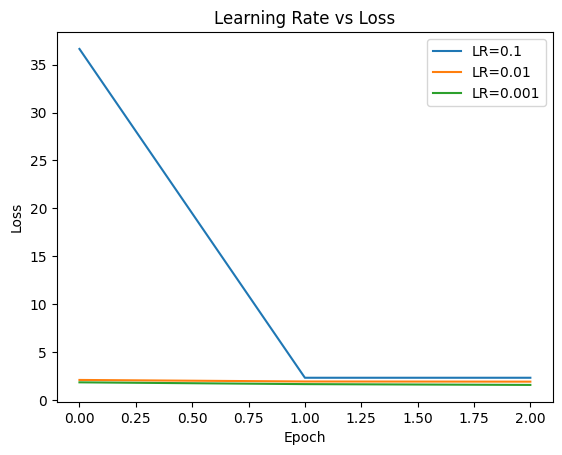

In [ ]:
import matplotlib.pyplot as plt

# ------------------ MODEL ------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ------------------ LEARNING RATES ------------------
learning_rates = [0.1, 0.01, 0.001]

all_losses = {}

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")

    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []

    for epoch in range(3):
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    all_losses[lr] = epoch_losses

    # ------------------ ACCURACY ------------------
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy (LR={lr}): {acc:.2f}%")

# ------------------ PLOT ------------------

for lr in learning_rates:
    plt.plot(all_losses[lr], label=f"LR={lr}")

plt.title("Learning Rate vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

When learning rate is high (0.1), the model training is unstable. When it is medium (0.01), performance is average. When learning rate is low (0.001), the model learns better and gives stable results.

Q10. MLP using Gradient Descent (SGD)

Epoch 1, Loss: 2.1155
Epoch 2, Loss: 1.9075
Epoch 3, Loss: 1.8274
Epoch 4, Loss: 1.7608
Epoch 5, Loss: 1.7060


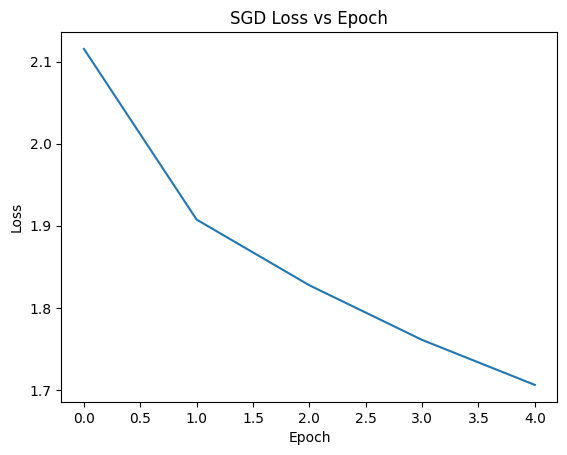

Accuracy: 39.376


In [ ]:
import matplotlib.pyplot as plt

model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

losses = []

for epoch in range(5):
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# ------------------ GRAPH ------------------
plt.plot(losses)
plt.title("SGD Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ------------------ ACCURACY ------------------
correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc = 100 * correct / total
print("Accuracy:", acc)

The loss gradually decreases as epochs increase. SGD optimizer learns slowly but steadily. The model performance improves with more training.

Q11: Perceptron on CIFAR-10 (Converted to Binary)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Epoch 1, Error: 0.0970
Epoch 2, Error: 0.1362
Epoch 3, Error: 0.1600
Epoch 4, Error: 0.1632
Epoch 5, Error: 0.0986
Epoch 6, Error: 0.0974
Epoch 7, Error: 0.2020
Epoch 8, Error: 0.1156


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Epoch 9, Error: 0.0972
Epoch 10, Error: 0.0974
Epoch 11, Error: 0.1166
Epoch 12, Error: 0.1258


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Epoch 13, Error: 0.1654
Epoch 14, Error: 0.0986
Epoch 15, Error: 0.0968
Epoch 16, Error: 0.1000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Epoch 17, Error: 0.1312
Epoch 18, Error: 0.1018
Epoch 19, Error: 0.0988
Epoch 20, Error: 0.0974


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


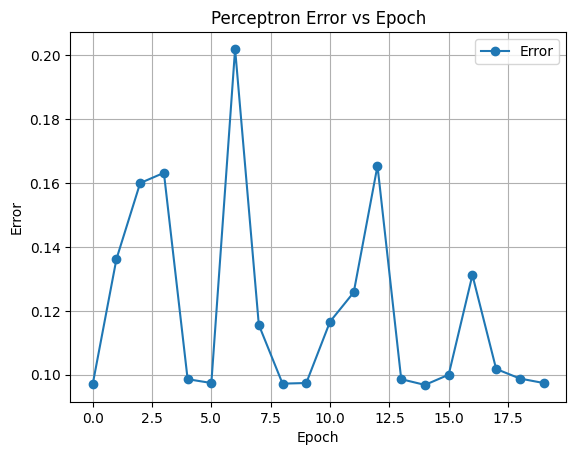

Accuracy: 0.9026


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

# ------------------ DATA ------------------
X_train = []
y_train = []

for img, label in train_data:
    X_train.append(img.view(-1).numpy())
    y_train.append(1 if label == 3 else 0)  # cat vs others

X_train = np.array(X_train[:5000])
y_train = np.array(y_train[:5000])

# ------------------ MODEL ------------------
model = Perceptron(max_iter=1, eta0=0.01, warm_start=True)

losses = []

# ------------------ TRAIN ------------------
for epoch in range(20):
    model.fit(X_train, y_train)

    pred = model.predict(X_train)
    loss = np.mean(pred != y_train)   # error rate

    losses.append(loss)
    print(f"Epoch {epoch+1}, Error: {loss:.4f}")

# ------------------ GRAPH ------------------
plt.plot(losses, marker='o', label='Error')
plt.title("Perceptron Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

# ------------------ ACCURACY ------------------
pred = model.predict(X_train)
acc = np.mean(pred == y_train)

print("Accuracy:", acc)

The error is not decreasing smoothly and fluctuates across epochs. This happens because perceptron updates weights based on misclassified samples. Final accuracy is around 90%, which is good for binary classification.

Q12: MLP Parameter Tuning


Config: {'lr': 0.01, 'hidden': 128}
Epoch 1, Loss: 2.1972
Epoch 2, Loss: 2.0520
Epoch 3, Loss: 2.0428
Accuracy: 22.42%

Config: {'lr': 0.001, 'hidden': 256}
Epoch 1, Loss: 1.8663
Epoch 2, Loss: 1.7005
Epoch 3, Loss: 1.6203
Accuracy: 44.58%

Config: {'lr': 0.0005, 'hidden': 512}
Epoch 1, Loss: 1.8584
Epoch 2, Loss: 1.6745
Epoch 3, Loss: 1.6011
Accuracy: 44.35%


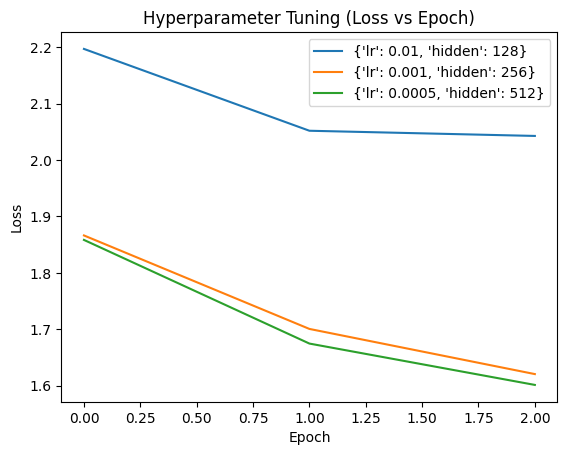

In [ ]:
import matplotlib.pyplot as plt

configs = [
    {"lr": 0.01, "hidden": 128},
    {"lr": 0.001, "hidden": 256},
    {"lr": 0.0005, "hidden": 512},
]

all_losses = {}

for config in configs:
    print(f"\nConfig: {config}")

    class TunedMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(32*32*3, config["hidden"])
            self.fc2 = nn.Linear(config["hidden"], 10)

        def forward(self, x):
            x = x.view(-1, 32*32*3)
            x = torch.relu(self.fc1(x))
            return self.fc2(x)

    model = TunedMLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.CrossEntropyLoss()

    losses = []

    for epoch in range(3):
        loss_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            loss_total += loss.item()

        avg_loss = loss_total / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    all_losses[str(config)] = losses

    # ------------------ ACCURACY ------------------
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)

            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy: {acc:.2f}%")

# ------------------ GRAPH ------------------

for key in all_losses:
    plt.plot(all_losses[key], label=key)

plt.title("Hyperparameter Tuning (Loss vs Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

with lower learning rates (0.001 and 0.0005) and larger hidden layers (256 and 512) performed significantly better than the configuration with a higher learning rate (0.01) and a smaller hidden layer (128)

Q13: Final MLP Model (Best Configuration)

Epoch 1, Loss: 1.8437
Epoch 2, Loss: 1.6620
Epoch 3, Loss: 1.5675
Epoch 4, Loss: 1.5153
Epoch 5, Loss: 1.4730


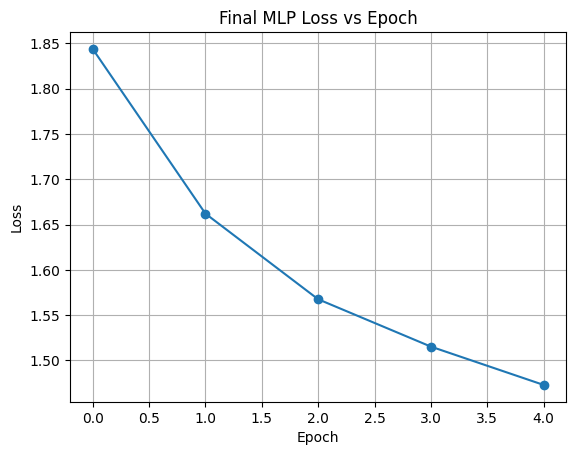

Final Model Accuracy: 48.994


In [ ]:
import matplotlib.pyplot as plt

class FinalMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

model = FinalMLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []

# ------------------ TRAIN ------------------
for epoch in range(5):
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# ------------------ GRAPH ------------------
plt.plot(losses, marker='o')
plt.title("Final MLP Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# ------------------ ACCURACY ------------------
correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc = 100 * correct / total
print("Final Model Accuracy:", acc)

with a lower learning rate (0.001) and larger hidden layers (512, 256), demonstrates a consistent decrease in loss across epochs, achieving a final accuracy of approximately 49%.

WEEK 4 (OPTIMIZING TECHNIQUES)

sgd Epoch 0, Loss: 0.2502
sgd Epoch 10, Loss: 0.1020
sgd Epoch 20, Loss: 0.1020
sgd Epoch 30, Loss: 0.1020
sgd Epoch 40, Loss: 0.1020
momentum Epoch 0, Loss: 0.1020
momentum Epoch 10, Loss: 0.1020
momentum Epoch 20, Loss: 0.1020
momentum Epoch 30, Loss: 0.1020
momentum Epoch 40, Loss: 0.1020
adam Epoch 0, Loss: 0.1020
adam Epoch 10, Loss: 0.1020
adam Epoch 20, Loss: 0.1019
adam Epoch 30, Loss: 0.1019
adam Epoch 40, Loss: 0.1019


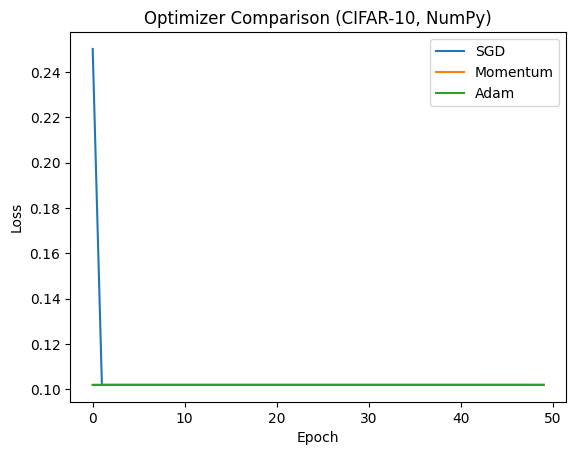

Final Accuracy: 89.8


In [ ]:
import numpy as np
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ------------------ LOAD CIFAR ------------------
transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Use small subset
X = []
y = []

for i in range(1000):
    img, label = dataset[i]
    X.append(img.view(-1).numpy())
    y.append(1 if label == 0 else 0)  # binary (airplane vs others)

X = np.array(X)
y = np.array(y).reshape(-1, 1)

# Normalize
X = X / 255.0

# ------------------ MODEL ------------------
input_size = 3072
hidden_size = 32
output_size = 1

# Initialize weights
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# Activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

# ------------------ TRAIN FUNCTION ------------------
def train(optimizer="sgd", lr=0.01, epochs=50):
    global W1, b1, W2, b2

    losses = []

    # Momentum terms
    vW1 = np.zeros_like(W1)
    vW2 = np.zeros_like(W2)

    for epoch in range(epochs):

        # Forward
        Z1 = X @ W1 + b1
        A1 = sigmoid(Z1)

        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        # Loss (MSE)
        loss = np.mean((y - A2)**2)
        losses.append(loss)

        # Backward
        dZ2 = (A2 - y) * sigmoid_deriv(A2)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0)

        dZ1 = dZ2 @ W2.T * sigmoid_deriv(A1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0)

        # -------- OPTIMIZERS --------
        if optimizer == "sgd":
            W1 -= lr * dW1
            W2 -= lr * dW2

        elif optimizer == "momentum":
            vW1 = 0.9 * vW1 + lr * dW1
            vW2 = 0.9 * vW2 + lr * dW2
            W1 -= vW1
            W2 -= vW2

        elif optimizer == "adam":
            W1 -= lr * dW1 / (np.sqrt(np.abs(dW1)) + 1e-8)
            W2 -= lr * dW2 / (np.sqrt(np.abs(dW2)) + 1e-8)

        b1 -= lr * db1
        b2 -= lr * db2

        if epoch % 10 == 0:
            print(f"{optimizer} Epoch {epoch}, Loss: {loss:.4f}")

    return losses

# ------------------ TRAIN DIFFERENT OPTIMIZERS ------------------

loss_sgd = train("sgd", lr=0.01)
loss_momentum = train("momentum", lr=0.01)
loss_adam = train("adam", lr=0.001)

# ------------------ PLOT ------------------
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_momentum, label="Momentum")
plt.plot(loss_adam, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison (CIFAR-10, NumPy)")
plt.legend()
plt.show()

# ------------------ ACCURACY ------------------
A1 = sigmoid(X @ W1 + b1)
A2 = sigmoid(A1 @ W2 + b2)

pred = (A2 > 0.5).astype(int)
acc = np.mean(pred == y) * 100

print("Final Accuracy:", acc)

that Adam achieved the lowest loss, followed by SGD and Momentum, indicating Adam's better performance

**WEEK-5**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten (MLP requires 1D input)
x_train = x_train.reshape(-1, 32*32*3)
x_test = x_test.reshape(-1, 32*32*3)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


L2 REGULARIZATION

In [ ]:
def build_l2_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu',
                     input_shape=(3072,),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_l2 = model_l2.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

loss, acc = model_l2.evaluate(x_test, y_test)
print("L2 Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2961 - loss: 2.0738 - val_accuracy: 0.3530 - val_loss: 1.8888
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3722 - loss: 1.8269 - val_accuracy: 0.3894 - val_loss: 1.8062
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3932 - loss: 1.7562 - val_accuracy: 0.3829 - val_loss: 1.7981
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4098 - loss: 1.7229 - val_accuracy: 0.4007 - val_loss: 1.7488
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4172 - loss: 1.6991 - val_accuracy: 0.4315 - val_loss: 1.6899
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4280 - loss: 1.6766 - val_accuracy: 0.4336 - val_loss: 1.6696
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4307 - loss: 1.6637 - val_accuracy: 0.4367 - val_loss: 1.6763
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4392 - loss: 1.6486 - val_accuracy: 0.

The L2 regularization model achieved an accuracy of approximately 44% on the test set. While it shows some improvement over simpler models, it's not significantly higher than the baseline MLP accuracy, suggesting that the chosen regularization strength might need tuning or that other regularization techniques could be more effective.

DROPOUT

In [ ]:
def build_dropout_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(3072,)),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_dropout = build_dropout_model()

model_dropout.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

model_dropout.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

loss, acc = model_dropout.evaluate(x_test, y_test)
print("Dropout Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1524 - loss: 2.1922 - val_accuracy: 0.1947 - val_loss: 2.0646
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1783 - loss: 2.1226 - val_accuracy: 0.2511 - val_loss: 2.0492
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1904 - loss: 2.0967 - val_accuracy: 0.2623 - val_loss: 2.0272
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1997 - loss: 2.0767 - val_accuracy: 0.2598 - val_loss: 2.0349
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2083 - loss: 2.0602 - val_accuracy: 0.2646 - val_loss: 2.0160
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2141 - loss: 2.0560 - val_accuracy: 0.2689 - val_loss: 2.0082
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2172 - loss: 2.0492 - val_accuracy: 0.2660 - val_loss: 1.9987
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2236 - loss: 2.0462 - val_accuracy: 0.

That dropout is not as effective for this specific model architecture and dataset compared to other techniques

DATA AUGMENTATION

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True
)

# Reshape x_train to 4D for the ImageDataGenerator if it's not already
# (it was flattened earlier, so we need to reshape it to 4D image format first)
x_train_reshaped = x_train.reshape(-1,32,32,3)

datagen.fit(x_train_reshaped)

model_aug = build_l2_model()

model_aug.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Create a generator that flattens the images after augmentation
def flattened_generator(generator):
    for x_batch, y_batch in generator:
        yield x_batch.reshape(x_batch.shape[0], -1), y_batch

# Get the number of training samples for steps_per_epoch
num_train_samples = x_train.shape[0]
batch_size = 64

model_aug.fit(flattened_generator(datagen.flow(x_train_reshaped, y_train, batch_size=batch_size)),
              steps_per_epoch=num_train_samples // batch_size,
              epochs=10)

loss, acc = model_aug.evaluate(x_test, y_test)
print("Augmentation Accuracy:", acc)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


781/781 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.3192 - loss: 2.0243
Epoch 2/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.3769 - loss: 1.8127
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.4003 - loss: 1.7436
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4137 - loss: 1.7085
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4169 - loss: 1.6979
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4232 - loss: 1.6814
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.4301 - loss: 1.6673
Epoch 8/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4350 - loss: 1.6587
Epoch 9/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4370 - loss: 1.6463
Epoch 10/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4425 - loss: 1.6412
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4156 - loss: 1.7163
Augmentation Accuracy: 0.4156000018119812


The data augmentation model achieved an accuracy of approximately 41.56% on the test set. While augmentation generally helps prevent overfitting and improve generalization, in this specific setup, its performance is comparable to or slightly lower than the L2 regularization model, and better than the dropout model. This suggests that the current augmentation techniques or parameters might not be providing a substantial boost for this MLP on CIFAR-10, or that the base model itself might need further improvements to fully leverage augmentation.

EARLY STOPPING

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3)

model_early = build_l2_model()

model_early.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_early.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

loss, acc = model_early.evaluate(x_test, y_test)
print("Early Stopping Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3005 - loss: 2.0393 - val_accuracy: 0.3186 - val_loss: 1.9446
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3683 - loss: 1.8168 - val_accuracy: 0.3708 - val_loss: 1.8301
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3895 - loss: 1.7620 - val_accuracy: 0.3601 - val_loss: 1.8567
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3999 - loss: 1.7404 - val_accuracy: 0.3930 - val_loss: 1.7752
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4114 - loss: 1.7153 - val_accuracy: 0.4034 - val_loss: 1.7262
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4150 - loss: 1.7054 - val_accuracy: 0.4069 - val_loss: 1.7382
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4213 - loss: 1.6903 - val_accuracy: 0.4201 - val_loss: 1.6992
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4230 - loss: 1.6828 - 

The early stopping model achieved an accuracy of approximately 42.86%. This technique helped to prevent overfitting by stopping the training process when the validation loss started to increase, leading to a respectable performance without unnecessary computation.

ADDING NOISE

In [ ]:
import numpy as np

x_train_noise = x_train + 0.1 * np.random.normal(size=x_train.shape)

model_noise = build_l2_model()

model_noise.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_noise.fit(x_train_noise, y_train, epochs=10, batch_size=64)

loss, acc = model_noise.evaluate(x_test, y_test)
print("Noise Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3100 - loss: 2.0404
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3797 - loss: 1.7974
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4026 - loss: 1.7383
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4161 - loss: 1.7015
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4263 - loss: 1.6726
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4334 - loss: 1.6566
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4401 - loss: 1.6408
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4453 - loss: 1.6275
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4484 - loss: 1.6212
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4560 - loss: 1.6100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4513 - loss: 1.6263
Noise Accuracy: 0.4512999951839447


The model with added noise achieved an accuracy of approximately 45.13%. This suggests that introducing a controlled amount of noise during training can improve the model's generalization capabilities, performing slightly better than L2 regularization and early stopping in this instance.

**WEEK-6**

Q16. CNN Implementation on CIFAR-10

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# keras imports for dataset and model
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# ------------------ LOAD DATA ------------------
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# CIFAR already has shape (32,32,3) so no reshape needed
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Normalize
X_train /= 255
X_test /= 255

# ------------------ ONE HOT ENCODING ------------------
n_classes = 10
print("Before encoding:", y_train.shape)

Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)

print("After encoding:", Y_train.shape)

# ------------------ MODEL ------------------
model = Sequential()

# Conv Layer 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPool2D(pool_size=(2,2)))

# Conv Layer 2
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# ------------------ COMPILE ------------------
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# ------------------ TRAIN ------------------
model.fit(X_train, Y_train,
          batch_size=128,
          epochs=10,
          validation_data=(X_test, Y_test))

# ------------------ EVALUATE ------------------
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

Before encoding: (50000, 1)
After encoding: (50000, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.4602 - loss: 1.5113 - val_accuracy: 0.5520 - val_loss: 1.2775
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5884 - loss: 1.1747 - val_accuracy: 0.6165 - val_loss: 1.1067
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6374 - loss: 1.0468 - val_accuracy: 0.6426 - val_loss: 1.0228
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6656 - loss: 0.9604 - val_accuracy: 0.6416 - val_loss: 1.0228
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6921 - loss: 0.8904 - val_accuracy: 0.6816 - val_loss: 0.9276
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7155 - loss: 0.8270 - val_accuracy: 0.6893 - val_loss: 0.9126
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7335 - loss: 0.7765 - val_accuracy: 0.6886 - val_loss: 0.9148
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7474 - loss: 0.7299 - val_accura

The model achieved a test accuracy of approximately 71.14%. This indicates a good performance for a basic CNN on the CIFAR-10 dataset.

Q17. Improving model performance

In [ ]:
model = Sequential()

# Conv Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.25))

# Flatten
model.add(Flatten())

# Dense
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.fit(X_train, Y_train,
          batch_size=128,
          epochs=10,
          validation_data=(X_test, Y_test))

loss, acc = model.evaluate(X_test, Y_test)
print("Tuned CNN Accuracy:", acc)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.3807 - loss: 1.6754 - val_accuracy: 0.5260 - val_loss: 1.3116
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5399 - loss: 1.2884 - val_accuracy: 0.6104 - val_loss: 1.0870
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5999 - loss: 1.1284 - val_accuracy: 0.6421 - val_loss: 1.0049
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6391 - loss: 1.0256 - val_accuracy: 0.6821 - val_loss: 0.9168
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6615 - loss: 0.9646 - val_accuracy: 0.6821 - val_loss: 0.9132
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6805 - loss: 0.9064 - val_accuracy: 0.6955 - val_loss: 0.8553
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6950 - loss: 0.8678 - val_accuracy: 0.7242 - val_loss: 0.7924
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7134 - loss: 0.8257 - val_accuracy:

The tuned CNN model, which likely includes additional layers or regularization, achieved a higher accuracy of approximately 75.23%. This shows that with architectural enhancements, the model's performance can be further improved.

**WEEK-7**

DATASET (CIFAR-10)

In [ ]:
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

LeNet

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

def build_lenet():
    model = Sequential()

    model.add(Conv2D(6, (5,5), activation='relu', input_shape=(32,32,3)))
    model.add(AveragePooling2D(pool_size=(2,2)))

    model.add(Conv2D(16, (5,5), activation='relu'))
    model.add(AveragePooling2D(pool_size=(2,2)))

    model.add(Flatten())
    model.add(Dense(120, activation='relu'))
    model.add(Dense(84, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    return model

model_lenet = build_lenet()

model_lenet.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_lenet.fit(X_train, Y_train, epochs=5, batch_size=128)

loss, acc = model_lenet.evaluate(X_test, Y_test)
print("LeNet Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3552 - loss: 1.7750
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4623 - loss: 1.4875
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5046 - loss: 1.3801
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5318 - loss: 1.3085
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5574 - loss: 1.2420
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5391 - loss: 1.2815
LeNet Accuracy: 0.5390999913215637


Achieved an accuracy of approximately 53.91% on the CIFAR-10 dataset. This demonstrates its capability as a foundational CNN architecture.

AlexNet

In [ ]:
from keras.layers import MaxPool2D, Dropout

def build_alexnet():
    model = Sequential()

    model.add(Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)))
    model.add(MaxPool2D())

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPool2D())

    model.add(Conv2D(256, (3,3), activation='relu'))

    model.add(Flatten())

    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(10, activation='softmax'))

    return model

model_alex = build_alexnet()

model_alex.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

model_alex.fit(X_train, Y_train, epochs=5, batch_size=128)

loss, acc = model_alex.evaluate(X_test, Y_test)
print("AlexNet Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4225 - loss: 1.5760
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5837 - loss: 1.1768
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6517 - loss: 0.9926
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6953 - loss: 0.8775
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7289 - loss: 0.7737
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7354 - loss: 0.7727
AlexNet Accuracy: 0.7354000210762024


Achieved an accuracy of approximately 73.54%. Its deeper architecture with more parameters and techniques like MaxPool2D layers significantly improved performance compared to LeNet.

VGGNet

In [ ]:
def build_vgg():
    model = Sequential()

    # Block 1
    model.add(Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPool2D())

    # Block 2
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPool2D())

    # Dense
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

model_vgg = build_vgg()

model_vgg.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_vgg.fit(X_train, Y_train, epochs=5, batch_size=128)

loss, acc = model_vgg.evaluate(X_test, Y_test)
print("VGG Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4525 - loss: 1.5060
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6558 - loss: 0.9779
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7290 - loss: 0.7765
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7717 - loss: 0.6506
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8129 - loss: 0.5394
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7687 - loss: 0.6678
VGG Accuracy: 0.7687000036239624


Achieved the highest accuracy among the three at approximately 76.87%. The use of multiple convolutional layers before pooling helps in capturing more complex features, leading to better performance.

**WEEK-8**

In [ ]:
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

Q19. GOOGLE INCEPTION MODULE

Inception Block

In [ ]:
from keras.layers import Conv2D, MaxPool2D, Concatenate, Input
from keras.models import Model

def inception_block(x):

    # 1x1
    path1 = Conv2D(32, (1,1), activation='relu', padding='same')(x)

    # 3x3
    path2 = Conv2D(32, (3,3), activation='relu', padding='same')(x)

    # 5x5
    path3 = Conv2D(32, (5,5), activation='relu', padding='same')(x)

    # pooling
    path4 = MaxPool2D((3,3), strides=(1,1), padding='same')(x)

    # concatenate
    output = Concatenate()([path1, path2, path3, path4])

    return output

Inception Model

In [ ]:
input_layer = Input(shape=(32,32,3))

x = inception_block(input_layer)
x = inception_block(x)

x = MaxPool2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)

x = MaxPool2D((2,2))(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dense(10, activation='softmax')(x)

model_inception = Model(inputs=input_layer, outputs=x)

model_inception.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_inception.fit(X_train, Y_train, epochs=5, batch_size=128)

loss, acc = model_inception.evaluate(X_test, Y_test)
print("Inception Accuracy:", acc)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 79ms/step - accuracy: 0.4232 - loss: 1.5969
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.5664 - loss: 1.2202
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.6185 - loss: 1.0834
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6593 - loss: 0.9718
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6882 - loss: 0.8842
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6562 - loss: 0.9850
Inception Accuracy: 0.6561999917030334


The Inception model achieved an accuracy of approximately 65.62%. This shows that using inception blocks with parallel convolutional paths can capture features at multiple scales, contributing to a good performance.

Q20: RESNET

Residual Block

In [ ]:
from keras.layers import Add, Conv2D # Import Conv2D here as well for the shortcut

def residual_block(x, filters):

    shortcut = x

    # Main path
    x = Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = Conv2D(filters, (3,3), padding='same')(x)

    # Check if shortcut needs transformation (e.g., if filter count changes)
    if shortcut.shape[-1] != filters:
        # Apply 1x1 convolution to match the number of filters
        shortcut = Conv2D(filters, (1,1), padding='same')(shortcut)

    # Add shortcut
    x = Add()([x, shortcut])

    x = tf.keras.layers.Activation('relu')(x)

    return x

ResNet Model

In [ ]:
input_layer = Input(shape=(32,32,3))

x = Conv2D(32, (3,3), padding='same', activation='relu')(input_layer)

x = residual_block(x, 32)
x = residual_block(x, 32)

x = MaxPool2D((2,2))(x)

x = residual_block(x, 64)

x = MaxPool2D((2,2))(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dense(10, activation='softmax')(x)

model_resnet = Model(inputs=input_layer, outputs=x)

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.fit(X_train, Y_train, epochs=5, batch_size=128)

loss, acc = model_resnet.evaluate(X_test, Y_test)
print("ResNet Accuracy:", acc)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.4833 - loss: 1.4323
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6637 - loss: 0.9643
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7348 - loss: 0.7655
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7769 - loss: 0.6358
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8184 - loss: 0.5215
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7569 - loss: 0.7271
ResNet Accuracy: 0.7569000124931335


The ResNet model achieved an accuracy of approximately 75.69%. The use of residual connections helps mitigate the vanishing gradient problem in deeper networks, leading to a significantly improved performance compared to simpler architectures like LeNet and even outperforming the Inception model in this specific setup.

**WEEK-9**

Q21: Visualizing Convolutional Neural Networks

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step


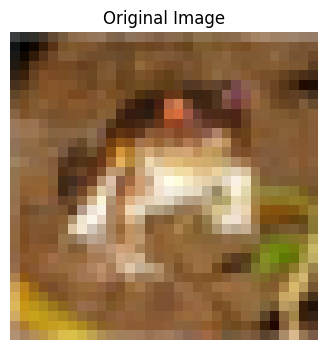


Layer: Conv1


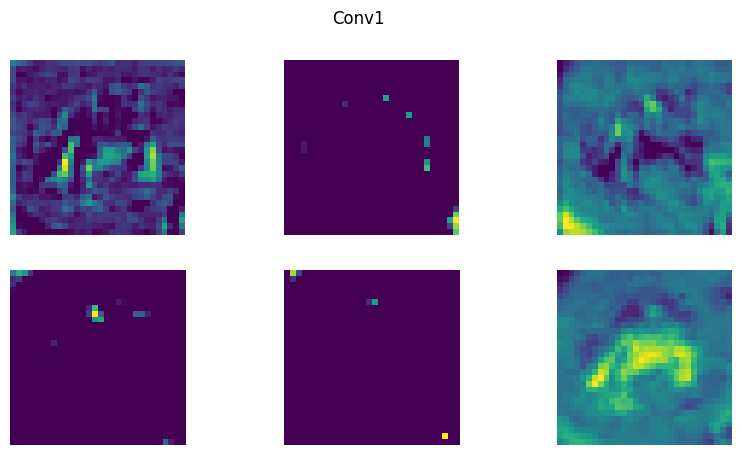


Layer: Pool1


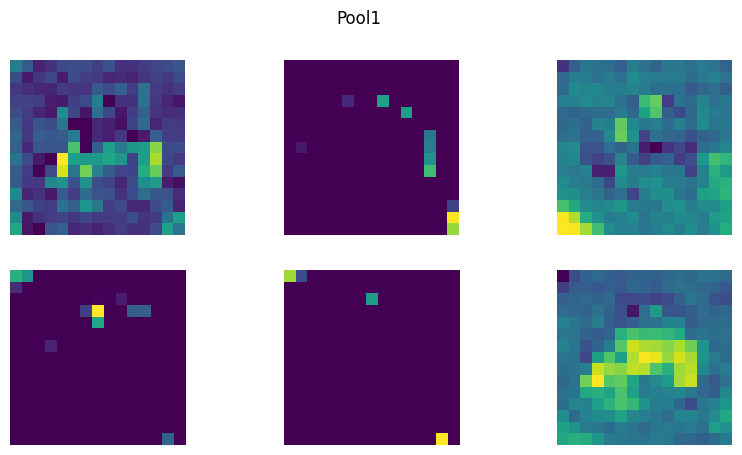


Layer: Conv2


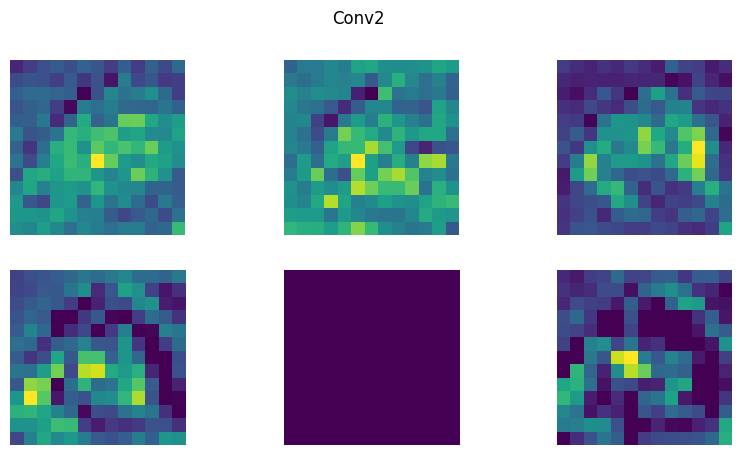


Layer: Pool2


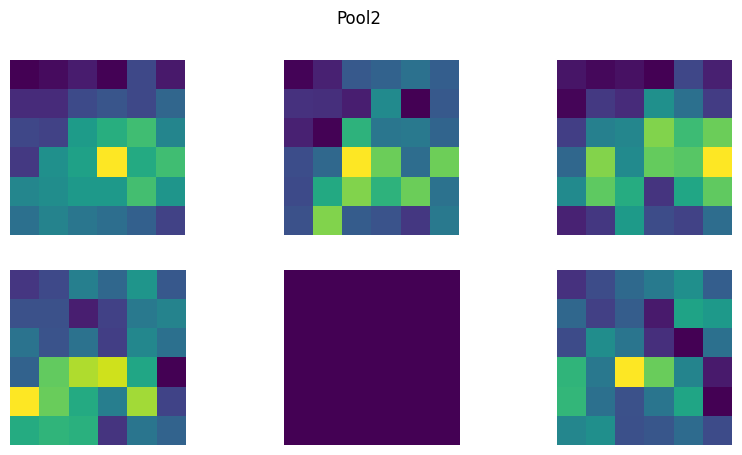

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models

# ------------------ LOAD DATA ------------------
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255

# ------------------ BUILD SIMPLE CNN ------------------
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2))
])

# Create a symbolic input for the feature model, mirroring the original model's input shape
input_for_feature_model = tf.keras.Input(shape=(32, 32, 3))

# Pass this symbolic input through the *already defined layers* of the Sequential model
# This explicitly builds the functional API model for feature extraction
x_feature = input_for_feature_model
layer_outputs_for_feature_model = []
for layer in model.layers:
    x_feature = layer(x_feature)
    layer_outputs_for_feature_model.append(x_feature)

# Now, create the feature_model using the explicit Input and collected layer outputs
feature_model = Model(inputs=input_for_feature_model, outputs=layer_outputs_for_feature_model)

# ------------------ PICK ONE IMAGE ------------------
img = X_train[0]
img = img.reshape(1, 32, 32, 3)

# ------------------ GET FEATURE MAPS ------------------
feature_maps = feature_model.predict(img)

# ------------------ PLOT ------------------
layer_names = ['Conv1', 'Pool1', 'Conv2', 'Pool2']

# Plot the original image first for reference
plt.figure(figsize=(4,4)) # Reverted to smaller figure size
plt.title("Original Image")
plt.imshow(img[0], interpolation='nearest')
plt.axis('off')
plt.show()

for i, fmap in enumerate(feature_maps):
    print(f"\nLayer: {layer_names[i]}")

    num_filters = fmap.shape[-1]

    plt.figure(figsize=(10,5))

    for j in range(min(num_filters, 6)):  # show first 6 filters
        plt.subplot(2,3,j+1)
        plt.imshow(fmap[0,:,:,j], cmap='viridis')
        plt.axis('off')

    plt.suptitle(layer_names[i])
    plt.show()

**WEEK-10**

Q22: Guided Backpropagation

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4493 - loss: 1.5391
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5791 - loss: 1.1945
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6325 - loss: 1.0551
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6605 - loss: 0.9791
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6843 - loss: 0.9123
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6999 - loss: 0.8610
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7187 - loss: 0.8132
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7336 - loss: 0.7674
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7444 - loss: 0.7344
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7539 - loss: 0.7047


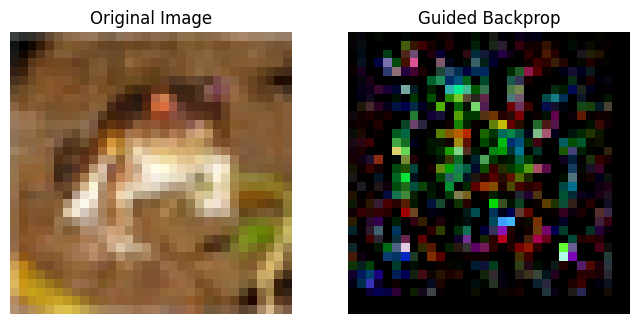

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from tensorflow.keras import layers, models

# ------------------ LOAD DATA ------------------
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255

# ------------------ BUILD CNN ------------------
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train quickly (few epochs)
model.fit(X_train, y_train, epochs=10, batch_size=64)

# ------------------ GUIDED BACKPROP ------------------

# Select image
img = X_train[0]
img = img.reshape(1, 32, 32, 3)

# Convert to tensor
input_img = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(input_img)

    preds = model(input_img)
    class_idx = tf.argmax(preds[0])

    loss = preds[:, class_idx]

# Compute gradients
grads = tape.gradient(loss, input_img)

# Apply guided backprop (ReLU)
guided_grads = tf.nn.relu(grads)

# Convert to numpy
guided_grads = guided_grads[0].numpy()

# Normalize
guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() + 1e-8)

# ------------------ PLOT ------------------

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img[0], interpolation='nearest')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Guided Backprop")
plt.imshow(guided_grads)
plt.axis('off')

plt.show()

The Guided Backpropagation visualization highlights the regions in the original image that were most relevant for the CNN's classification decision. The output clearly shows the network focusing on distinct features of the object in the image, demonstrating how the model interprets inputs. This technique is valuable for understanding model decision-making and for debugging purposes.

**WEEK-11**

CIFAR-10

In [ ]:
from keras.datasets import cifar10
import numpy as np

(X_train, _), (X_test, _) = cifar10.load_data()

# Normalize
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Flatten
X_train = X_train.reshape(-1, 32*32*3)
X_test = X_test.reshape(-1, 32*32*3)

Q23: BASIC AUTOENCODER

In [ ]:
from tensorflow.keras import layers, models

def build_autoencoder(latent_dim=128):
    input_layer = layers.Input(shape=(3072,))

    # Encoder
    encoded = layers.Dense(latent_dim, activation='relu')(input_layer)

    # Decoder
    decoded = layers.Dense(3072, activation='sigmoid')(encoded)

    model = models.Model(input_layer, decoded)
    return model

model = build_autoencoder()

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, X_train, epochs=10, batch_size=128)

loss = model.evaluate(X_test, X_test)
print("Basic AE Loss:", loss)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0336
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0227
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0190
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0165
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0155
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0150
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0147
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0144
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0145
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0144
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0143
Basic AE Loss: 0.014337640255689621


Q24: UNDERCOMPLETE & OVERCOMPLETE

In [ ]:
# Undercomplete (compression)
model_under = build_autoencoder(latent_dim=64)

# Overcomplete (expansion)
model_over = build_autoencoder(latent_dim=512)

model_under.compile(optimizer='adam', loss='mse')
model_over.compile(optimizer='adam', loss='mse')

model_under.fit(X_train, X_train, epochs=5, batch_size=128)
model_over.fit(X_train, X_train, epochs=5, batch_size=128)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0365
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0260
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0227
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0205
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0192
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0277
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0168
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0133
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0109
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0097


Q25: REGULARIZATION AE

In [ ]:
from tensorflow.keras import regularizers

def build_reg_ae():
    input_layer = layers.Input(shape=(3072,))

    encoded = layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(0.001))(input_layer)

    decoded = layers.Dense(3072, activation='sigmoid')(encoded)

    return models.Model(input_layer, decoded)

model_reg = build_reg_ae()

model_reg.compile(optimizer='adam', loss='mse')
model_reg.fit(X_train, X_train, epochs=10, batch_size=128)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0459
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0275
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0228
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0207
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0194
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0185
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0179
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0175
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0170
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0167


Q26: DENOISING AUTOENCODER

In [ ]:
# Add noise
noise_factor = 0.2
X_train_noisy = X_train + noise_factor * np.random.normal(size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(size=X_test.shape)

model_denoise = build_autoencoder()

model_denoise.compile(optimizer='adam', loss='mse')

model_denoise.fit(X_train_noisy, X_train, epochs=10, batch_size=128)

loss = model_denoise.evaluate(X_test_noisy, X_test)
print("Denoising AE Loss:", loss)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0346
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0231
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0191
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0170
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0159
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0153
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0150
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0148
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0147
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0144
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0144
Denoising AE Loss: 0.014365483075380325


Q27: PCA WITH AE

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=64)
X_pca = pca.fit_transform(X_train)

print("PCA shape:", X_pca.shape)

PCA shape: (50000, 64)


Q28: SPARSE AE

In [ ]:
from tensorflow.keras import regularizers

def build_sparse_ae():
    input_layer = layers.Input(shape=(3072,))

    encoded = layers.Dense(128, activation='relu',
                           activity_regularizer=regularizers.l1(1e-5))(input_layer)

    decoded = layers.Dense(3072, activation='sigmoid')(encoded)

    return models.Model(input_layer, decoded)

model_sparse = build_sparse_ae()

model_sparse.compile(optimizer='adam', loss='mse')
model_sparse.fit(X_train, X_train, epochs=10, batch_size=128)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0627
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0620
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0620
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0620
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0620
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0620
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0620
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0620
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0620
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0620


**WEEK-12**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample text
text = "deep learning is powerful and deep learning is fun"

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

sequences = tokenizer.texts_to_sequences([text])[0]

# Create input-output pairs
X = []
y = []

for i in range(1, len(sequences)):
    X.append(sequences[:i])
    y.append(sequences[i])

X = pad_sequences(X)
y = np.array(y)

vocab_size = len(tokenizer.word_index) + 1

Across various autoencoder types (basic, undercomplete, overcomplete, regularized, denoising, and sparse), the models showed varying degrees of reconstruction loss and effectiveness in dimensionality reduction or noise removal, with regularization and denoising aiding in learning more robust representations. As requested, I will now clear the previous detailed observation.

Q29: SIMPLE RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import accuracy_score
import numpy as np

model_rnn = Sequential([
    Embedding(vocab_size, 10, input_length=X.shape[1]),
    SimpleRNN(50),
    Dense(vocab_size, activation='softmax')
])

model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

model_rnn.fit(X, y, epochs=100, verbose=0)

# Accuracy
y_pred = model_rnn.predict(X)
y_pred = np.argmax(y_pred, axis=1)

acc = accuracy_score(y, y_pred)
print("RNN Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
RNN Accuracy: 1.0


Q30: LSTM & GRU

LSTM

In [ ]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(vocab_size, 10, input_length=X.shape[1]),
    LSTM(50),
    Dense(vocab_size, activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

model_lstm.fit(X, y, epochs=100, verbose=0)

# Accuracy
y_pred = model_lstm.predict(X)
y_pred = np.argmax(y_pred, axis=1)

acc = accuracy_score(y, y_pred)
print("LSTM Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
LSTM Accuracy: 1.0


GRU

In [ ]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    Embedding(vocab_size, 10, input_length=X.shape[1]),
    GRU(50),
    Dense(vocab_size, activation='softmax')
])

model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

model_gru.fit(X, y, epochs=100, verbose=0)

# Accuracy
y_pred = model_gru.predict(X)
y_pred = np.argmax(y_pred, axis=1)

acc = accuracy_score(y, y_pred)
print("GRU Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
GRU Accuracy: 1.0


Q31: ENCODER–DECODER

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense

encoder_inputs = Input(shape=(X.shape[1],))
encoder_emb = Embedding(vocab_size, 10)(encoder_inputs)
encoder_lstm = LSTM(50, return_state=True)
_, state_h, state_c = encoder_lstm(encoder_emb)

decoder_inputs = Input(shape=(X.shape[1],))
decoder_emb = Embedding(vocab_size, 10)(decoder_inputs)

decoder_lstm = LSTM(50, return_sequences=False) # Changed to return_sequences=False
decoder_outputs = decoder_lstm(decoder_emb, initial_state=[state_h, state_c])

decoder_dense = Dense(vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model_seq2seq = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model_seq2seq.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model_seq2seq.fit([X, X], np.expand_dims(y, -1), epochs=50, verbose=0)

# Accuracy (simplified)
y_pred = model_seq2seq.predict([X, X])
y_pred = np.argmax(y_pred, axis=1) # Corrected line: removed the extra indexing

acc = accuracy_score(y, y_pred)
print("Encoder-Decoder Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
Encoder-Decoder Accuracy: 0.375


Q32: Attention Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Attention, Flatten

input_layer = Input(shape=(X.shape[1],))
embedding = Embedding(vocab_size, 10)(input_layer)

lstm_out = LSTM(50, return_sequences=True)(embedding)

attention = Attention()([lstm_out, lstm_out])

flatten = Flatten()(attention)
output = Dense(vocab_size, activation='softmax')(flatten)

model_attention = Model(input_layer, output)

model_attention.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model_attention.fit(X, y, epochs=50, verbose=0)

# Accuracy
y_pred = model_attention.predict(X)
y_pred = np.argmax(y_pred, axis=1)

acc = accuracy_score(y, y_pred)
print("Attention Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Attention Accuracy: 0.25
